In [1]:
# ============================================================
#   CREDIT CARD FRAUD DETECTION — XGBoost (Google Colab)
# ============================================================

# ── CELL 1 : Install & Import ─────────────────────────────
!pip install kagglehub[pandas-datasets] xgboost imbalanced-learn -q

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, matthews_corrcoef
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, plot_importance


# Plotting style
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a",
    "axes.facecolor":   "#1a1a2e",
    "axes.edgecolor":   "#333355",
    "axes.labelcolor":  "#e0e0ff",
    "xtick.color":      "#aaaacc",
    "ytick.color":      "#aaaacc",
    "text.color":       "#e0e0ff",
    "grid.color":       "#2a2a4a",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
})
ACCENT  = "#00d4ff"
FRAUD   = "#ff4466"
LEGIT   = "#00d4aa"
WARN    = "#ffaa00"

print("  All libraries imported successfully.")

  All libraries imported successfully.


In [2]:

# ── CELL 2 : Load Dataset ─────────────────────────────────
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    "creditcard.csv",
)
print(f"Dataset shape : {df.shape}")
print(df.head())

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset shape : (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0


  EXPLORATORY DATA ANALYSIS

Shape            : (284807, 31)
Missing values   : 0
Duplicate rows   : 1081

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud %          : 0.1727%


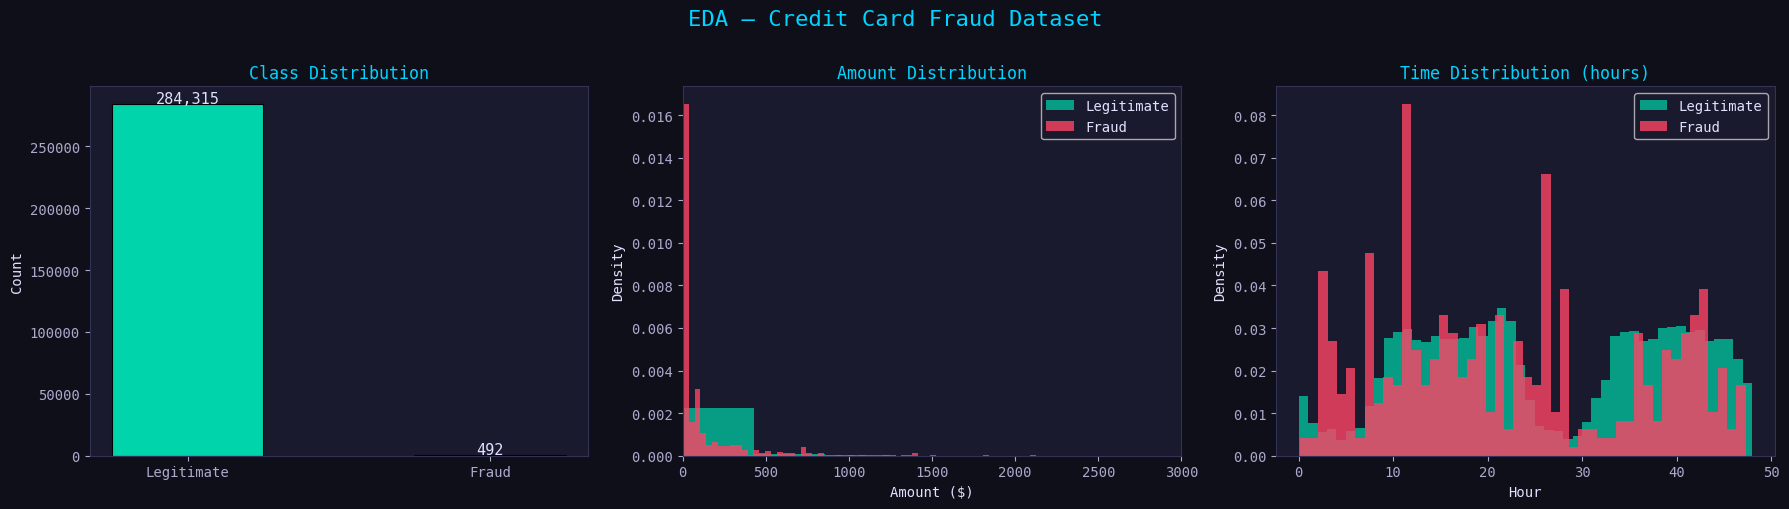

  EDA plot saved.


In [3]:
# ── CELL 3 : Exploratory Data Analysis ────────────────────
print("\n" + "="*60)
print("  EXPLORATORY DATA ANALYSIS")
print("="*60)
print(f"\nShape            : {df.shape}")
print(f"Missing values   : {df.isnull().sum().sum()}")
print(f"Duplicate rows   : {df.duplicated().sum()}")
print(f"\nClass distribution:\n{df['Class'].value_counts()}")
print(f"\nFraud %          : {df['Class'].mean()*100:.4f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA — Credit Card Fraud Dataset", fontsize=16, color=ACCENT, y=1.01)

# 1. Class imbalance bar
counts = df["Class"].value_counts()
bars = axes[0].bar(["Legitimate", "Fraud"], counts.values,
                   color=[LEGIT, FRAUD], edgecolor="#000", linewidth=0.8, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{val:,}", ha="center", fontsize=11, color="#e0e0ff")
axes[0].set_title("Class Distribution", color=ACCENT)
axes[0].set_ylabel("Count")

# 2. Transaction amount distribution
axes[1].hist(df[df["Class"]==0]["Amount"], bins=60, alpha=0.7, color=LEGIT,  label="Legitimate", density=True)
axes[1].hist(df[df["Class"]==1]["Amount"], bins=60, alpha=0.8, color=FRAUD,  label="Fraud",      density=True)
axes[1].set_title("Amount Distribution", color=ACCENT)
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].set_xlim(0, 3000)

# 3. Transaction time
axes[2].hist(df[df["Class"]==0]["Time"]/3600, bins=48, alpha=0.7, color=LEGIT, label="Legitimate", density=True)
axes[2].hist(df[df["Class"]==1]["Time"]/3600, bins=48, alpha=0.8, color=FRAUD, label="Fraud",      density=True)
axes[2].set_title("Time Distribution (hours)", color=ACCENT)
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("  EDA plot saved.")

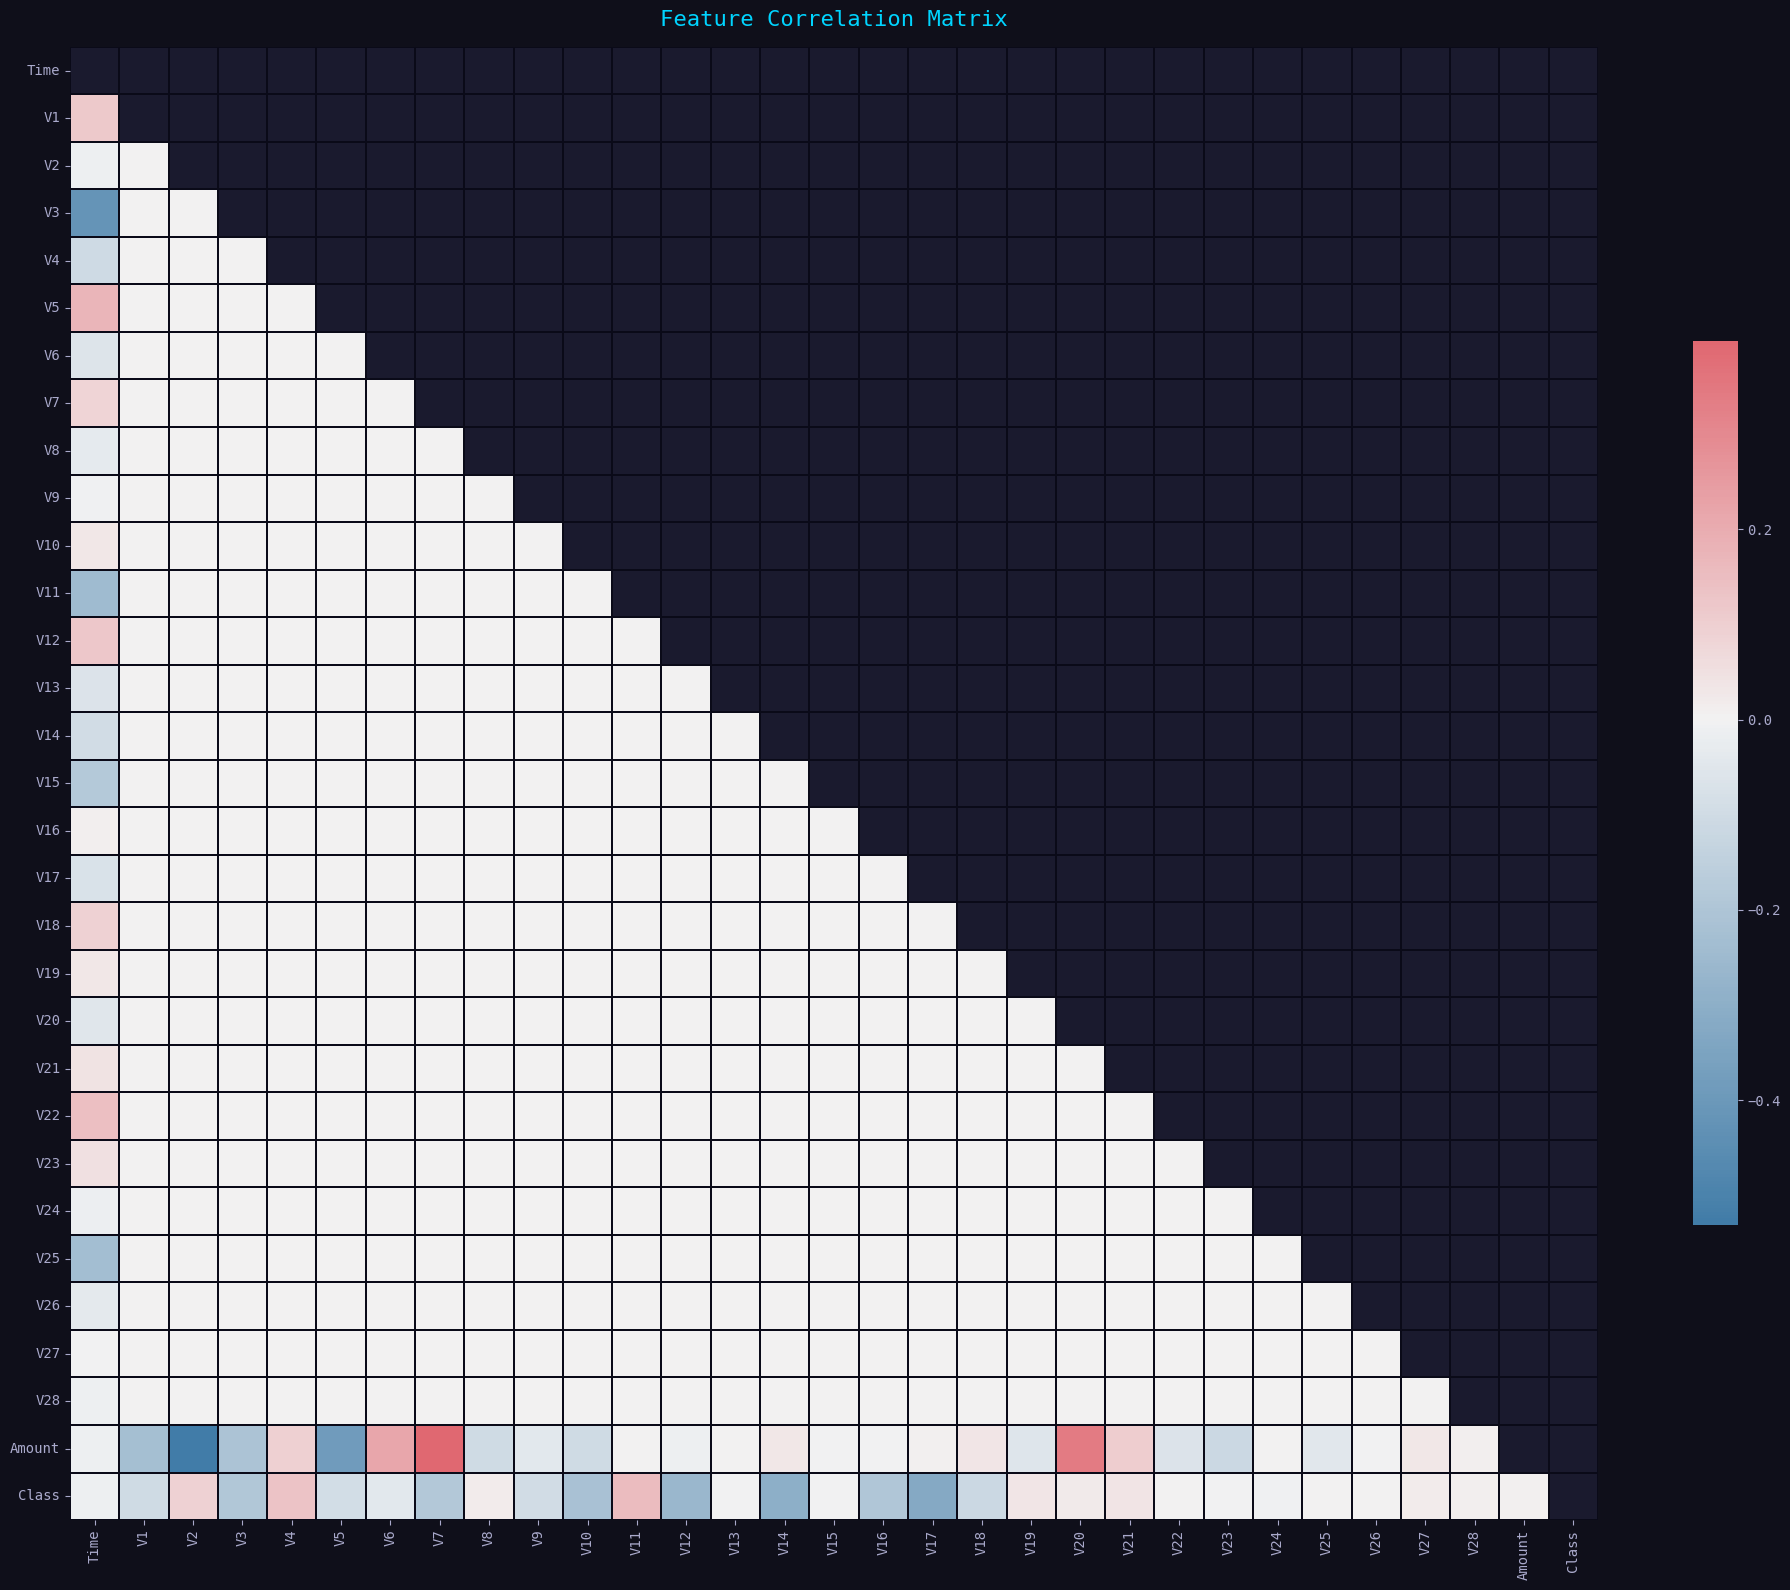

 Correlation heatmap saved.


In [4]:
# ── CELL 4 : Correlation Heat-map ─────────────────────────
fig, ax = plt.subplots(figsize=(20, 16))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, ax=ax,
            linewidths=0.3, linecolor="#0a0a18",
            cbar_kws={"shrink": 0.6})
ax.set_title("Feature Correlation Matrix", fontsize=16, color=ACCENT, pad=15)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Correlation heatmap saved.")


In [5]:
# ── CELL 5 : Preprocessing ────────────────────────────────
print("\n" + "="*60)
print("  PREPROCESSING")
print("="*60)

# 5a. Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicates → {len(df)} rows remain.")

# 5b. Scale Amount & Time (RobustScaler handles outliers better)
scaler = RobustScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"]   = scaler.fit_transform(df[["Time"]])
df = df.drop(columns=["Amount", "Time"])
print("  Amount and Time scaled with RobustScaler.")

# 5c. Feature / target split
X = df.drop(columns=["Class"])
y = df["Class"]
feature_names = X.columns.tolist()
print(f"Features : {X.shape[1]}   |   Samples : {X.shape[0]}")

# 5d. Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]}  |  Test : {X_test.shape[0]}")
print(f"Train fraud % : {y_train.mean()*100:.3f}%")
print(f"Test  fraud % : {y_test.mean()*100:.3f}%")

# 5e. SMOTE oversampling on training set only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train shape : {X_train_res.shape}")
print(f"Class balance after SMOTE :\n{pd.Series(y_train_res).value_counts()}")




  PREPROCESSING
Removed 1081 duplicates → 283726 rows remain.
  Amount and Time scaled with RobustScaler.
Features : 30   |   Samples : 283726
Train : 226980  |  Test : 56746
Train fraud % : 0.167%
Test  fraud % : 0.167%

After SMOTE — Train shape : (453204, 30)
Class balance after SMOTE :
Class
0    226602
1    226602
Name: count, dtype: int64


In [6]:
# ── CELL 6 : Train XGBoost ────────────────────────────────
print("\n" + "="*60)
print("  TRAINING XGBoost MODEL")
print("="*60)

xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = 1,          # balanced via SMOTE
    use_label_encoder = False,
    eval_metric       = "aucpr",
    random_state      = 42,
    n_jobs            = -1,
    tree_method       = "hist",     # fast on Colab
)

xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
print("\n XGBoost training complete.")




  TRAINING XGBoost MODEL
[0]	validation_0-aucpr:0.50040
[50]	validation_0-aucpr:0.69003
[100]	validation_0-aucpr:0.77184
[150]	validation_0-aucpr:0.78302
[200]	validation_0-aucpr:0.78809
[250]	validation_0-aucpr:0.79750
[299]	validation_0-aucpr:0.80571

 XGBoost training complete.


In [7]:

# ── CELL 7 : Predictions ──────────────────────────────────
y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Find optimal threshold via F1 on test set
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
y_pred_opt  = (y_pred_proba >= best_thresh).astype(int)
print(f"Optimal threshold (max-F1) : {best_thresh:.2f}")



Optimal threshold (max-F1) : 0.89


In [8]:

# ── CELL 8 : Metrics ──────────────────────────────────────
print("\n" + "="*60)
print("  MODEL PERFORMANCE METRICS")
print("="*60)

roc_auc  = roc_auc_score(y_test, y_pred_proba)
avg_prec = average_precision_score(y_test, y_pred_proba)
f1       = f1_score(y_test, y_pred_opt)
acc      = accuracy_score(y_test, y_pred_opt)
mcc      = matthews_corrcoef(y_test, y_pred_opt)

print(f"  Accuracy              : {acc*100:.4f}%")
print(f"  ROC-AUC               : {roc_auc:.6f}")
print(f"  Average Precision     : {avg_prec:.6f}")
print(f"  F1-Score (opt thresh) : {f1:.6f}")
print(f"  Matthews Corr Coef    : {mcc:.6f}")
print(f"\n{classification_report(y_test, y_pred_opt, target_names=['Legitimate','Fraud'])}")




  MODEL PERFORMANCE METRICS
  Accuracy              : 99.9401%
  ROC-AUC               : 0.968623
  Average Precision     : 0.806004
  F1-Score (opt thresh) : 0.811111
  Matthews Corr Coef    : 0.812070

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.86      0.77      0.81        95

    accuracy                           1.00     56746
   macro avg       0.93      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [9]:

# ── CELL 9 : Cross-Validation ─────────────────────────────
print("\n" + "="*60)
print("  5-FOLD STRATIFIED CROSS-VALIDATION")
print("="*60)

cv_xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric="aucpr",
    random_state=42, n_jobs=-1, tree_method="hist",
)
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(cv_xgb, X_train, y_train,
                         cv=skf, scoring="roc_auc", n_jobs=-1)

print(f"  CV ROC-AUC scores : {cv_auc}")
print(f"  Mean  : {cv_auc.mean():.6f}")
print(f"  Std   : {cv_auc.std():.6f}")




  5-FOLD STRATIFIED CROSS-VALIDATION
  CV ROC-AUC scores : [0.98267205 0.97699962 0.97762664 0.98541744 0.99080109]
  Mean  : 0.982703
  Std   : 0.005123


In [10]:

# ── CELL 10 : Visualization Dashboard ─────────────────────
fig = plt.figure(figsize=(22, 20))
fig.suptitle("XGBoost — Credit Card Fraud Detection Results",
             fontsize=20, color=ACCENT, fontweight="bold", y=1.002)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)


<Figure size 2200x2000 with 0 Axes>

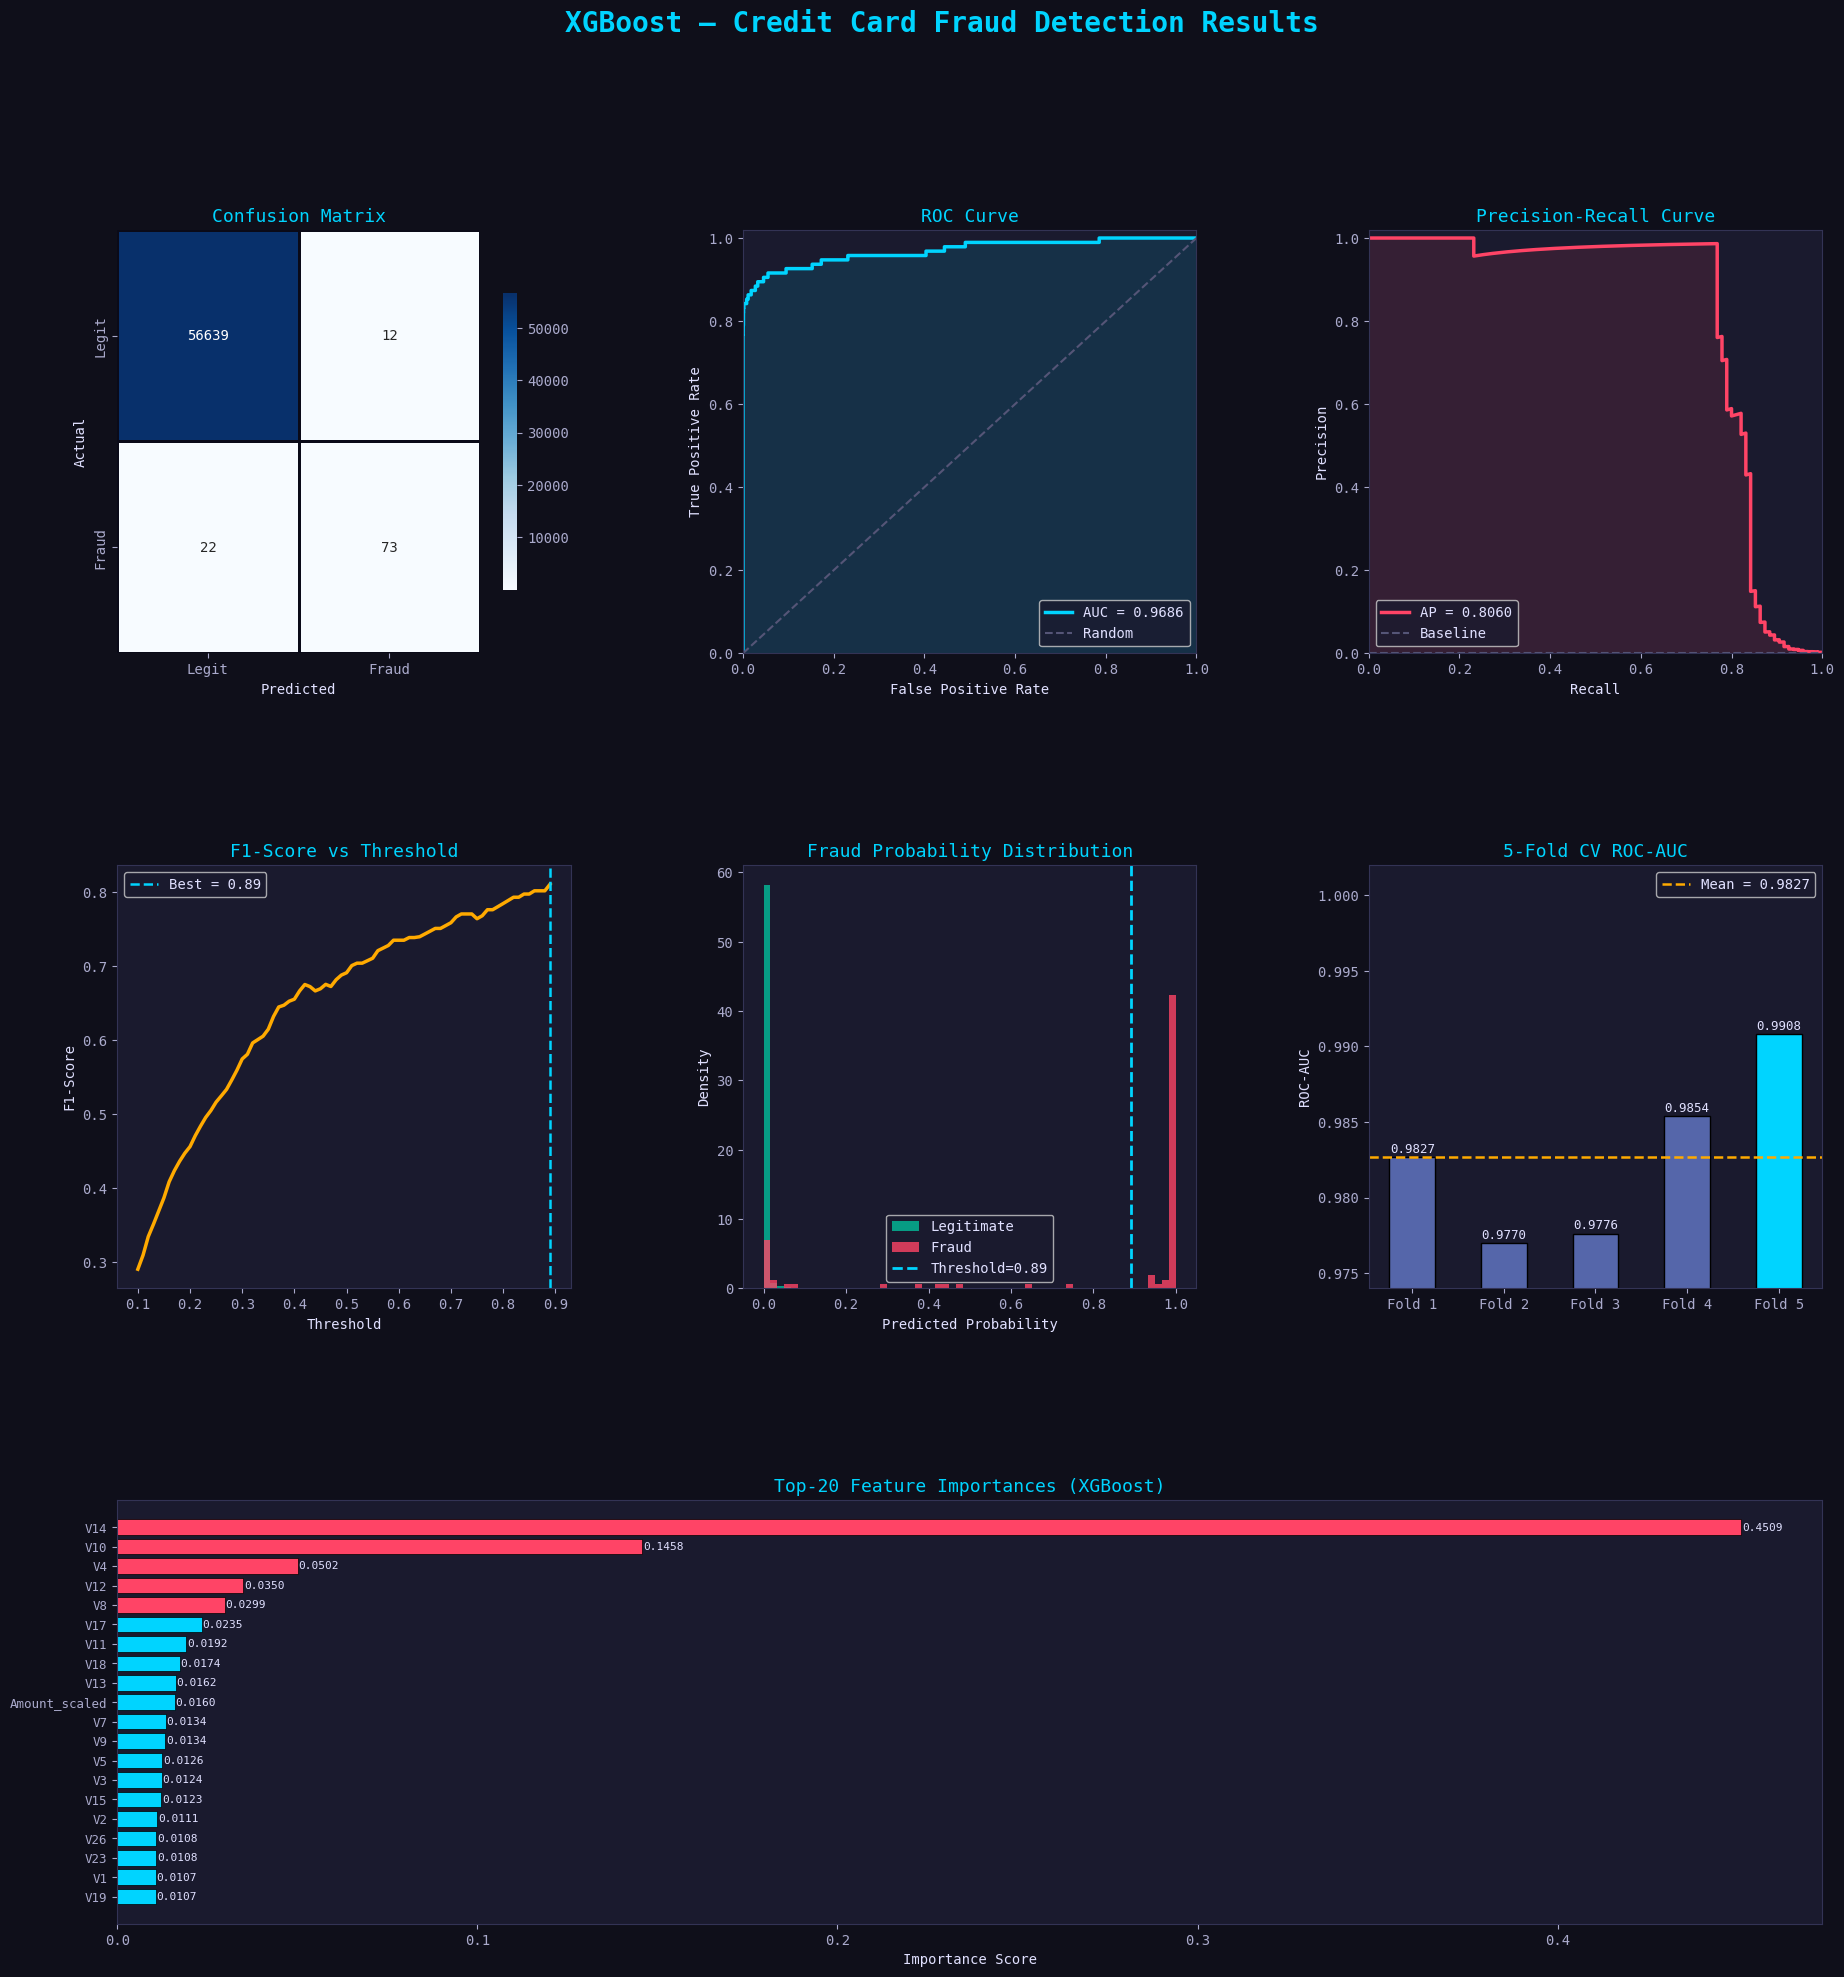

 Dashboard saved as 'xgboost_dashboard.png'


In [18]:
# ── CELL 10 : Visualization Dashboard (FIXED for Colab) ────
%matplotlib inline

fig = plt.figure(figsize=(22, 22), facecolor="#0f0f1a")
fig.suptitle("XGBoost — Credit Card Fraud Detection Results",
             fontsize=20, color=ACCENT, fontweight="bold", y=0.98)  #  y changed from 1.002 → 0.98
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

# ── Plot 1 : Confusion Matrix ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=["Legit","Fraud"], yticklabels=["Legit","Fraud"],
            linewidths=1, linecolor="#0a0a18",
            cbar_kws={"shrink": 0.7})
ax1.set_title("Confusion Matrix", color=ACCENT, fontsize=13)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")

# ── Plot 2 : ROC Curve ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, color=ACCENT, lw=2.5, label=f"AUC = {roc_auc:.4f}")
ax2.fill_between(fpr, tpr, alpha=0.12, color=ACCENT)
ax2.plot([0,1],[0,1],"--", color="#555577", lw=1.5, label="Random")
ax2.set_title("ROC Curve", color=ACCENT, fontsize=13)
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.legend(loc="lower right")
ax2.set_xlim(0,1); ax2.set_ylim(0,1.02)

# ── Plot 3 : Precision-Recall Curve ───────────────────────
ax3 = fig.add_subplot(gs[0, 2])
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_pred_proba)
ax3.plot(recall_arr, precision_arr, color=FRAUD, lw=2.5,
         label=f"AP = {avg_prec:.4f}")
ax3.fill_between(recall_arr, precision_arr, alpha=0.12, color=FRAUD)
ax3.axhline(y_test.mean(), color="#555577", ls="--", lw=1.5, label="Baseline")
ax3.set_title("Precision-Recall Curve", color=ACCENT, fontsize=13)
ax3.set_xlabel("Recall"); ax3.set_ylabel("Precision")
ax3.legend(); ax3.set_xlim(0,1); ax3.set_ylim(0,1.02)

# ── Plot 4 : F1 vs Threshold ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(thresholds, f1_scores, color=WARN, lw=2.5)
ax4.axvline(best_thresh, color=ACCENT, ls="--", lw=1.8,
            label=f"Best = {best_thresh:.2f}")
ax4.set_title("F1-Score vs Threshold", color=ACCENT, fontsize=13)
ax4.set_xlabel("Threshold"); ax4.set_ylabel("F1-Score")
ax4.legend()

# ── Plot 5 : Prediction Score Distribution ────────────────
ax5 = fig.add_subplot(gs[1, 1])
y_test_arr      = y_test.values          #  Convert Series → numpy array
y_pred_proba_arr = np.array(y_pred_proba)

ax5.hist(y_pred_proba_arr[y_test_arr == 0], bins=60, alpha=0.7, color=LEGIT,
         label="Legitimate", density=True)
ax5.hist(y_pred_proba_arr[y_test_arr == 1], bins=60, alpha=0.8, color=FRAUD,
         label="Fraud", density=True)
ax5.axvline(best_thresh, color=ACCENT, ls="--", lw=2,
            label=f"Threshold={best_thresh:.2f}")
ax5.set_title("Fraud Probability Distribution", color=ACCENT, fontsize=13)
ax5.set_xlabel("Predicted Probability"); ax5.set_ylabel("Density")
ax5.legend()

# ── Plot 6 : Cross-Validation Scores ──────────────────────
ax6 = fig.add_subplot(gs[1, 2])
fold_labels = [f"Fold {i+1}" for i in range(len(cv_auc))]
colors_cv   = [ACCENT if v == cv_auc.max() else "#5566aa" for v in cv_auc]
bars_cv     = ax6.bar(fold_labels, cv_auc, color=colors_cv, edgecolor="#000", width=0.5)
for bar, val in zip(bars_cv, cv_auc):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
             f"{val:.4f}", ha="center", fontsize=9, color="#e0e0ff")
ax6.axhline(cv_auc.mean(), color=WARN, ls="--", lw=1.8,
            label=f"Mean = {cv_auc.mean():.4f}")
ax6.set_title("5-Fold CV ROC-AUC", color=ACCENT, fontsize=13)
ax6.set_ylabel("ROC-AUC"); ax6.legend()
ax6.set_ylim(cv_auc.min() - 0.003, 1.002)

# ── Plot 7 : Feature Importance (Top 20) ──────────────────
ax7 = fig.add_subplot(gs[2, :])
importance = xgb_model.feature_importances_
feat_df    = pd.DataFrame({"Feature": feature_names, "Importance": importance})
feat_df    = feat_df.sort_values("Importance", ascending=True).tail(20)

colors_fi = [FRAUD if v > feat_df["Importance"].quantile(0.75) else ACCENT
             for v in feat_df["Importance"]]
bars_fi   = ax7.barh(feat_df["Feature"], feat_df["Importance"],
                     color=colors_fi, edgecolor="#000", linewidth=0.5)
for bar, val in zip(bars_fi, feat_df["Importance"]):
    ax7.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=8, color="#e0e0ff")
ax7.set_title("Top-20 Feature Importances (XGBoost)", color=ACCENT, fontsize=13)
ax7.set_xlabel("Importance Score")
ax7.tick_params(axis="y", labelsize=9)

# Save BEFORE plt.show() — show() clears the figure in Colab
plt.savefig("xgboost_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f1a")
plt.show()
print(" Dashboard saved as 'xgboost_dashboard.png'")

In [12]:
# ── CELL 11 : Final Summary ───────────────────────────────
print("\n" + "="*60)
print("  FINAL SUMMARY")
print("="*60)

tp = cm[1,1]; fp = cm[0,1]; fn = cm[1,0]; tn = cm[0,0]
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision   = tp / (tp + fp)

summary = {
    "Total Test Samples"    : len(y_test),
    "Fraud Cases in Test"   : int(y_test.sum()),
    "Accuracy"              : f"{acc*100:.4f}%",
    "ROC-AUC"               : f"{roc_auc:.6f}",
    "Average Precision"     : f"{avg_prec:.6f}",
    "F1-Score"              : f"{f1:.6f}",
    "Matthews Corr Coef"    : f"{mcc:.6f}",
    "Sensitivity (Recall)"  : f"{sensitivity:.6f}",
    "Specificity"           : f"{specificity:.6f}",
    "Precision"             : f"{precision:.6f}",
    "True Positives"        : tp,
    "False Positives"       : fp,
    "True Negatives"        : tn,
    "False Negatives"       : fn,
    "CV Mean ROC-AUC"       : f"{cv_auc.mean():.6f}",
    "CV Std  ROC-AUC"       : f"{cv_auc.std():.6f}",
    "Optimal Threshold"     : f"{best_thresh:.2f}",
}

for k, v in summary.items():
    print(f"  {k:<28}: {v}")

print("\n Credit Card Fraud Detection pipeline complete!")


  FINAL SUMMARY
  Total Test Samples          : 56746
  Fraud Cases in Test         : 95
  Accuracy                    : 99.9401%
  ROC-AUC                     : 0.968623
  Average Precision           : 0.806004
  F1-Score                    : 0.811111
  Matthews Corr Coef          : 0.812070
  Sensitivity (Recall)        : 0.768421
  Specificity                 : 0.999788
  Precision                   : 0.858824
  True Positives              : 73
  False Positives             : 12
  True Negatives              : 56639
  False Negatives             : 22
  CV Mean ROC-AUC             : 0.982703
  CV Std  ROC-AUC             : 0.005123
  Optimal Threshold           : 0.89

 Credit Card Fraud Detection pipeline complete!


In [13]:
# ============================================================
#  CUSTOM PREDICTION (INFERENCE)
# ============================================================

def predict_transaction(model, input_dict, threshold=0.5):
    """
    model       : trained XGBoost model
    input_dict  : dictionary with feature values
    threshold   : decision threshold
    """

    # Convert to DataFrame
    input_df = pd.DataFrame([input_dict])

    # Ensure column order matches training
    input_df = input_df[X_train.columns]

    # Predict probability
    proba = model.predict_proba(input_df)[:, 1][0]

    # Apply threshold
    prediction = int(proba >= threshold)

    return {
        "Fraud Probability": round(proba, 6),
        "Prediction": "FRAUD 🚨" if prediction == 1 else "LEGIT ✅",
        "Threshold Used": threshold
    }

In [14]:
custom_input = {
    col: 0 for col in X_train.columns
}

# Simulate suspicious transaction
custom_input["V14"] = -5
custom_input["V10"] = -3
custom_input["Amount_scaled"] = 2.5
custom_input["Time_scaled"] = 0.5

result = predict_transaction(
    model=xgb_model,
    input_dict=custom_input,
    threshold=best_thresh
)

print(result)

{'Fraud Probability': np.float32(0.965018), 'Prediction': 'FRAUD 🚨', 'Threshold Used': np.float64(0.8899999999999996)}


In [15]:
# Create 5 different custom transactions
test_inputs = []

for i in range(5):
    custom_input = {col: 0 for col in X_train.columns}

    # Simulate different suspicious patterns
    custom_input["V14"] = -5 + i      # slightly varying
    custom_input["V10"] = -3 + i*0.5
    custom_input["Amount_scaled"] = 2.5 + i*0.2
    custom_input["Time_scaled"] = 0.5 + i*0.1

    test_inputs.append(custom_input)

# Run predictions for all 5
results = []
for idx, input_data in enumerate(test_inputs):
    result = predict_transaction(
        model=xgb_model,
        input_dict=input_data,
        threshold=best_thresh
    )
    results.append(result)
    print(f"Transaction {idx+1}: {result}")

Transaction 1: {'Fraud Probability': np.float32(0.965018), 'Prediction': 'FRAUD 🚨', 'Threshold Used': np.float64(0.8899999999999996)}
Transaction 2: {'Fraud Probability': np.float32(0.89534), 'Prediction': 'FRAUD 🚨', 'Threshold Used': np.float64(0.8899999999999996)}
Transaction 3: {'Fraud Probability': np.float32(0.816362), 'Prediction': 'LEGIT ✅', 'Threshold Used': np.float64(0.8899999999999996)}
Transaction 4: {'Fraud Probability': np.float32(0.789422), 'Prediction': 'LEGIT ✅', 'Threshold Used': np.float64(0.8899999999999996)}
Transaction 5: {'Fraud Probability': np.float32(0.542609), 'Prediction': 'LEGIT ✅', 'Threshold Used': np.float64(0.8899999999999996)}


In [16]:
import joblib

# Save
joblib.dump(xgb_model, "fraud_model.pkl")

# Load later
model = joblib.load("fraud_model.pkl")